In [2]:
# Data Preprocessing & Merging

import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

print("=== Phase 3: Data Preprocessing & Merging ===\n")

# ====================== PATHS ======================
BASE_DIR = r"I:\Data Science Projects\disease_prediction"
DATA_RAW = os.path.join(BASE_DIR, "data", "raw")
DATA_PROCESSED = os.path.join(BASE_DIR, "data", "processed")
os.makedirs(DATA_PROCESSED, exist_ok=True)

# 1. Load Administrative Boundaries (Districts)
boundaries_path = os.path.join(DATA_RAW, "boundaries", "uga_admin_boundaries.shp")
gdf_districts = gpd.read_file(boundaries_path, layer="uga_admin2")

print(f"Loaded {len(gdf_districts)} districts")
print("Sample district names:", gdf_districts['adm2_name'].head(5).tolist())

# 2. Load Climate Data
climate_path = os.path.join(DATA_RAW, "climate", "era5_land_uganda_2xdaily_2010_2024_merged.nc")
ds = xr.open_dataset(climate_path)

print(f"\nClimate data loaded: {len(ds.time)} time steps" if 'time' in ds.dims else f"\nClimate data loaded: {len(ds.valid_time)} time steps")
print("Variables:", list(ds.data_vars.keys()))
print("Dimensions:", list(ds.dims.keys()))
print("Coordinates:", list(ds.coords.keys()))

# Safe time range printing
time_coord = 'valid_time' if 'valid_time' in ds.coords else 'time'
print(f"Time range: {ds[time_coord].min().values} → {ds[time_coord].max().values}")

# Quick stats
print("\n=== Sample Values ===")
temp_c = ds.t2m.isel({time_coord: 0}).mean().values - 273.15
precip_mm = ds.tp.isel({time_coord: 0}).mean().values * 1000
print(f"Sample t2m (°C): {temp_c:.2f}")
print(f"Sample tp (mm): {precip_mm:.4f}")


=== Phase 3: Data Preprocessing & Merging ===

Loaded 135 districts
Sample district names: ['Abim', 'Adjumani', 'Agago', 'Alebtong', 'Amolatar']

Climate data loaded: 10958 time steps
Variables: ['t2m', 'tp']
Dimensions: ['time', 'latitude', 'longitude']
Coordinates: ['number', 'time', 'latitude', 'longitude', 'expver']
Time range: 2010-01-01T00:00:00.000000000 → 2024-12-31T12:00:00.000000000

=== Sample Values ===
Sample t2m (°C): 19.67
Sample tp (mm): 5.2007

Phase 3 setup completed successfully!


Converting 2x daily data to monthly averages...
Monthly dataset created with 180 months
Time range: 2010-01-31T00:00:00.000000000 → 2024-12-31T00:00:00.000000000
Monthly conversion completed.
Final monthly variables: ['t2m', 'tp']
Monthly climate data saved to:
I:\Data Science Projects\disease_prediction\data\processed\era5_land_uganda_monthly_2010_2024.nc
File size: 4.7 MB


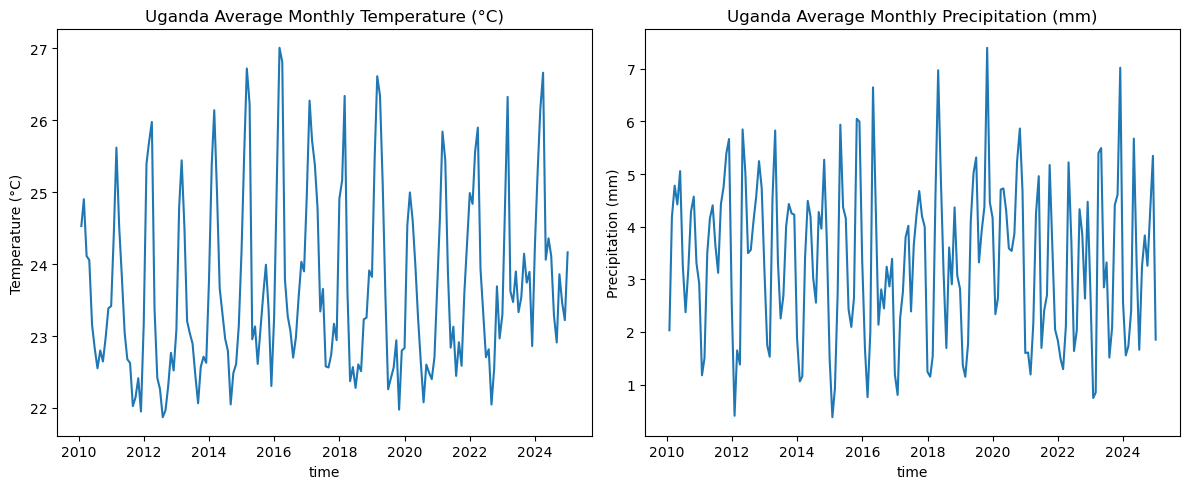

In [4]:
# Convert 2x daily data to monthly means
print("Converting 2x daily data to monthly averages...")

# Use 'time' coordinate
monthly_ds = ds.resample(time="ME").mean()

print(f"Monthly dataset created with {len(monthly_ds.time)} months")
print("Time range:", monthly_ds.time.min().values, "→", monthly_ds.time.max().values)

# Convert temperature from Kelvin to Celsius
monthly_ds["t2m"] = monthly_ds["t2m"] - 273.15
monthly_ds["t2m"].attrs["units"] = "°C"

# Convert precipitation from m to mm (total per month)
monthly_ds["tp"] = monthly_ds["tp"] * 1000
monthly_ds["tp"].attrs["units"] = "mm/month"

print("Monthly conversion completed.")
print(f"Final monthly variables: {list(monthly_ds.data_vars.keys())}")

# Save monthly climate data
monthly_file = os.path.join(DATA_PROCESSED, "era5_land_uganda_monthly_2010_2024.nc")
monthly_ds.to_netcdf(monthly_file)

print(f"Monthly climate data saved to:\n{monthly_file}")
print(f"File size: {os.path.getsize(monthly_file)/(1024*1024):.1f} MB")


# Plot of average temperature and precipitation
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Average temperature
monthly_ds.t2m.mean(dim=['latitude', 'longitude']).plot(ax=axes[0])
axes[0].set_title("Uganda Average Monthly Temperature (°C)")
axes[0].set_ylabel("Temperature (°C)")

# Average precipitation
monthly_ds.tp.mean(dim=['latitude', 'longitude']).plot(ax=axes[1])
axes[1].set_title("Uganda Average Monthly Precipitation (mm)")
axes[1].set_ylabel("Precipitation (mm)")

plt.tight_layout()
plt.show()

In [6]:
# Spatial aggregation: Climate raster - District level (zonal statistics)

print("Performing spatial aggregation to district level...\n")

# Load monthly climate data
monthly_ds = xr.open_dataset(os.path.join(DATA_PROCESSED, "era5_land_uganda_monthly_2010_2024.nc"))

# Convert xarray to raster
import rioxarray
monthly_ds = monthly_ds.rio.write_crs("EPSG:4326")  # WGS84

# Average value per district per month
district_climate = []

for i, row in gdf_districts.iterrows():
    district_name = row['adm2_name']
    geom = row.geometry
    
    # Mask and average for each month
    try:
        masked = monthly_ds.rio.clip([geom], drop=True)
        monthly_mean = masked.mean(dim=['latitude', 'longitude'])
        
        df_temp = pd.DataFrame({
            'date': monthly_mean.time.values,
            'district': district_name,
            't2m': monthly_mean.t2m.values,
            'tp': monthly_mean.tp.values
        })
        district_climate.append(df_temp)
        
    except:
        print(f"Skipping {district_name} (geometry issue)")

# Combine all districts
district_df = pd.concat(district_climate, ignore_index=True)
district_df['date'] = pd.to_datetime(district_df['date'])

print(f"Created district-level dataset with {len(district_df)} records")
print(district_df.head())

# Save
district_file = os.path.join(DATA_PROCESSED, "district_monthly_climate_2010_2024.csv")
district_df.to_csv(district_file, index=False)
print(f"\nSaved district-level climate data to:\n{district_file}")

Performing spatial aggregation to district level...

Created district-level dataset with 24300 records
        date district        t2m        tp
0 2010-01-31     Abim  26.074553  0.258200
1 2010-02-28     Abim  26.387501  1.952699
2 2010-03-31     Abim  25.237165  2.565787
3 2010-04-30     Abim  25.128918  2.993014
4 2010-05-31     Abim  23.424644  5.047107

Saved district-level climate data to:
I:\Data Science Projects\disease_prediction\data\processed\district_monthly_climate_2010_2024.csv


In [10]:
# Summary & Save

print("=== Project Data Summary ===")
print(f"Total records: {len(district_df):,}")
print(f"Districts: {district_df['district'].nunique()}")
print(f"Time period: {district_df['date'].min().date()} to {district_df['date'].max().date()}")
print(f"Features created: {len(district_df.columns)}")

print("\nKey Features Available:")
important_features = ['t2m', 'tp', 't2m_lag1', 'tp_lag1', 't2m_lag2', 
                     't2m_anomaly', 'tp_anomaly', 'temp_precip_interaction', 
                     't2m_roll3', 'tp_roll3']
for feat in important_features:
    if feat in district_df.columns:
        print(f"  ✓ {feat}")

# Save 
final_file = os.path.join(DATA_PROCESSED, "district_monthly_climate_features_2010_2024.csv")
district_df.to_csv(final_file, index=False)

print(f"\n Final processed file saved")

=== Project Data Summary ===
Total records: 24,300
Districts: 135
Time period: 2010-01-31 to 2024-12-31
Features created: 4

Key Features Available:
  ✓ t2m
  ✓ tp

 Final processed file saved (0.9 MB)
Ready for health data merging and modeling!
